# Proyecto 0: Análisis Exploratorio del S&P 500

## Obtención de datos

Fuente de datos: Yahoo Finance

Ticker utilizado: ^GSPC

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Descargar datos del S&P 500
sp500 = yf.download("^GSPC", period="5y")

[*********************100%***********************]  1 of 1 completed


In [3]:
# Dimensión
sp500.shape

(1255, 5)

## Exploración de datos

In [4]:
# Mostrar la primeras filas
sp500.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2021-06-10,4239.180176,4249.740234,4220.339844,4228.560059,4408210000
2021-06-11,4247.439941,4248.379883,4232.250000,4242.899902,3815010000
2021-06-14,4255.149902,4255.589844,4234.069824,4248.310059,4151200000
2021-06-15,4246.589844,4257.160156,4238.350098,4255.279785,4048940000
2021-06-16,4223.700195,4251.890137,4202.450195,4248.870117,4538350000


In [5]:
# Mostrar últimas filas
sp500.tail()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2026-06-03,7553.680176,7605.350098,7551.220215,7605.310059,5753860000
2026-06-04,7584.310059,7598.189941,7516.540039,7516.540039,5398910000
2026-06-05,7383.740234,7541.810059,7368.629883,7537.359863,5591290000
2026-06-08,7405.729980,7466.810059,7395.129883,7440.569824,4898180000
2026-06-09,7386.649902,7483.149902,7237.850098,7438.660156,3499231000


In [6]:
# Información
sp500.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-10 to 2026-06-09
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   1255 non-null   float64
 1   (High, ^GSPC)    1255 non-null   float64
 2   (Low, ^GSPC)     1255 non-null   float64
 3   (Open, ^GSPC)    1255 non-null   float64
 4   (Volume, ^GSPC)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [7]:
sp500.describe()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,5120.224995,5147.204571,5089.200993,5119.154887,4.473752e+09
std,1033.256258,1033.713310,1031.383774,1032.983550,1.017467e+09
min,3577.030029,3608.340088,3491.580078,3520.370117,0.000000e+00
25%,4285.675049,4301.185059,4258.590088,4279.949951,3.814605e+09
50%,4713.069824,4743.830078,4699.439941,4721.040039,4.270710e+09
75%,5948.939941,5979.800049,5903.889893,5944.510010,5.021645e+09
max,7609.779785,7620.899902,7582.990234,7605.310059,1.002582e+10


In [8]:
print("Fecha más antigua:", sp500.index.min())
print("Fecha más reciente:", sp500.index.max())
print("Número de registros:", len(sp500))

Fecha más antigua: 2021-06-10 00:00:00
Fecha más reciente: 2026-06-09 00:00:00
Número de registros: 1255


## Visualización

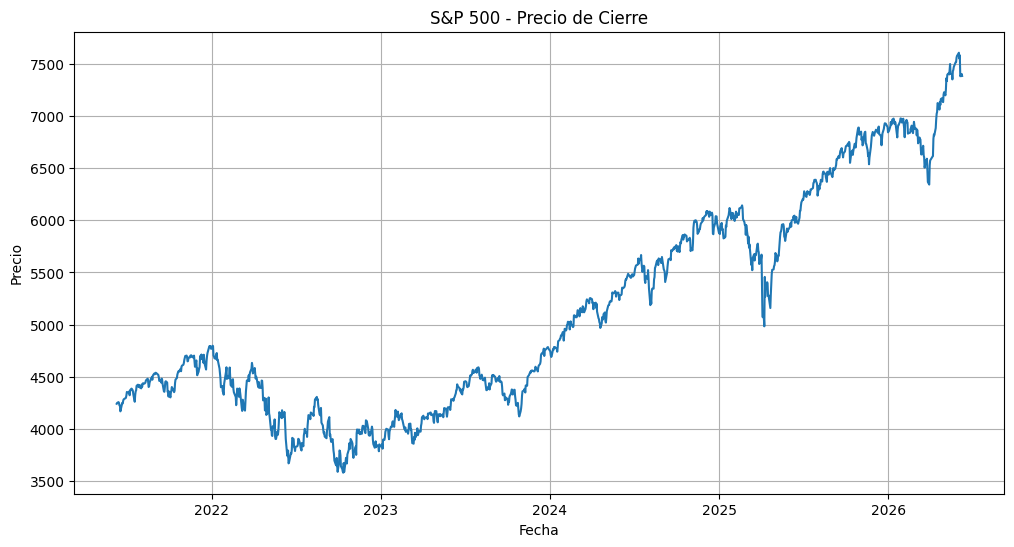

In [9]:
plt.figure(figsize=(12,6))

plt.plot(sp500.index, sp500["Close"])

plt.title("S&P 500 - Precio de Cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(True)

plt.show()

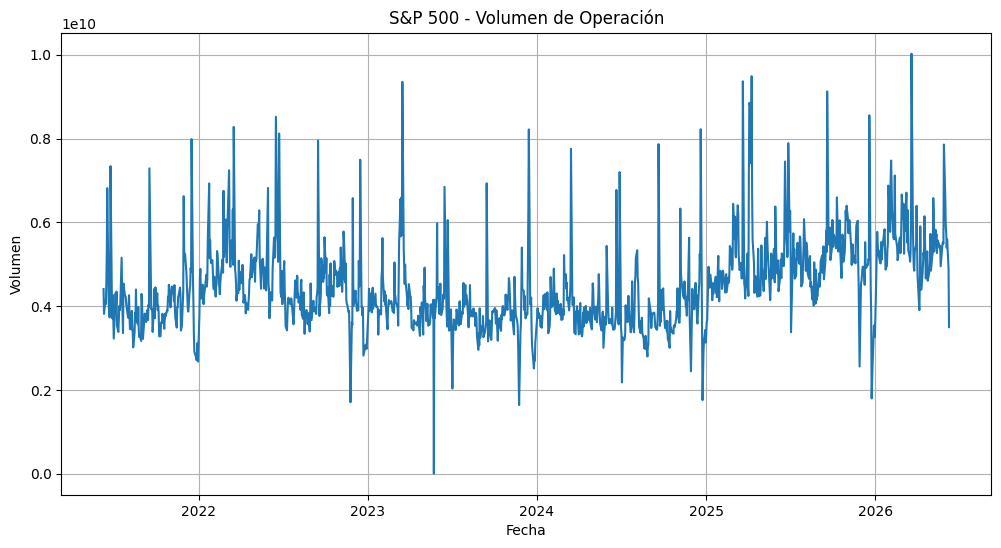

In [10]:
plt.figure(figsize=(12,6))

plt.plot(sp500.index, sp500["Volume"])

plt.title("S&P 500 - Volumen de Operación")
plt.xlabel("Fecha")
plt.ylabel("Volumen")
plt.grid(True)

plt.show()

### Observaciones visuales. 

- El precio del índice muestra una tendencia alsista.
- En 2022 el precio del índice mostró una tendencia descendente.

## Rendimientos

In [11]:
# Rendimientos diarios
sp500["Daily_Return"] = sp500["Close"].pct_change()
sp500[["Close","Daily_Return"]].head()

Price,Close,Daily_Return
Ticker,^GSPC,
Date,,
2021-06-10,4239.180176,NaN
2021-06-11,4247.439941,0.001948
2021-06-14,4255.149902,0.001815
2021-06-15,4246.589844,-0.002012
2021-06-16,4223.700195,-0.005390


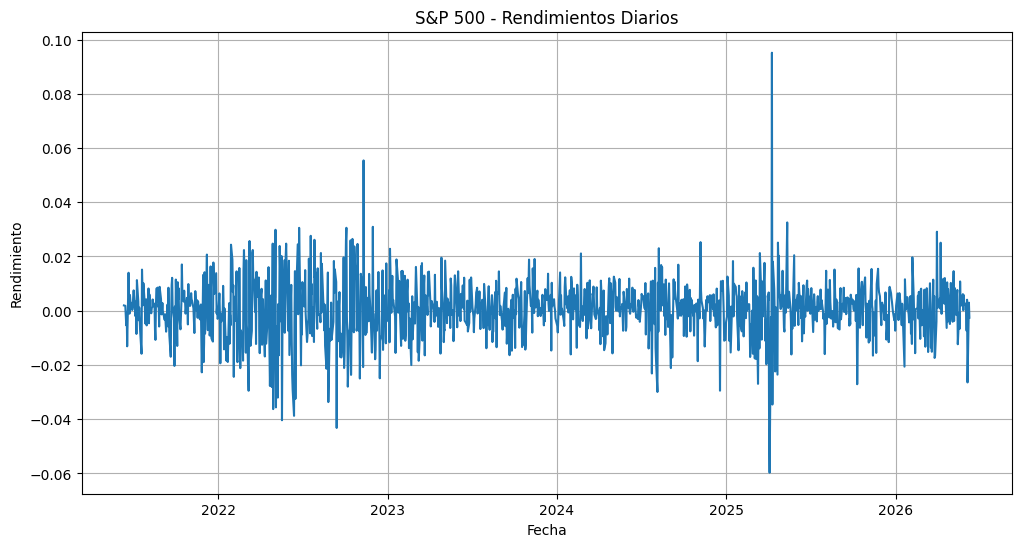

In [12]:
# Gráfica de rendimientos diarios
plt.figure(figsize=(12,6))

plt.plot(sp500.index, sp500["Daily_Return"])

plt.title("S&P 500 - Rendimientos Diarios")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")

plt.grid(True)

plt.show()

## Estadística Descriptiva

In [13]:
sp500["Daily_Return"].describe()

count    1254.000000
mean        0.000500
std         0.010675
min        -0.059750
25%        -0.004680
50%         0.000838
75%         0.006162
max         0.095154
Name: Daily_Return, dtype: float64

In [14]:
# Mejor día
print("Mejor día")
print(sp500["Daily_Return"].idxmax())
print(sp500["Daily_Return"].max())

# Peor día
print("\nPeor día")
print(sp500["Daily_Return"].idxmin())
print(sp500["Daily_Return"].min())

Mejor día
2025-04-09 00:00:00
0.09515387644904849

Peor día
2025-04-04 00:00:00
-0.05974960534553109


## Media móvil de 30 días

In [15]:
sp500["MA_30"] = sp500["Close"].rolling(window=30).mean()

In [16]:
sp500[["Close", "MA_30"]].head(35)

Price,Close,MA_30
Ticker,^GSPC,
Date,,
2021-06-10,4239.180176,NaN
2021-06-11,4247.439941,NaN
2021-06-14,4255.149902,NaN
2021-06-15,4246.589844,NaN
2021-06-16,4223.700195,NaN
2021-06-17,4221.859863,NaN
2021-06-18,4166.450195,NaN
2021-06-21,4224.790039,NaN


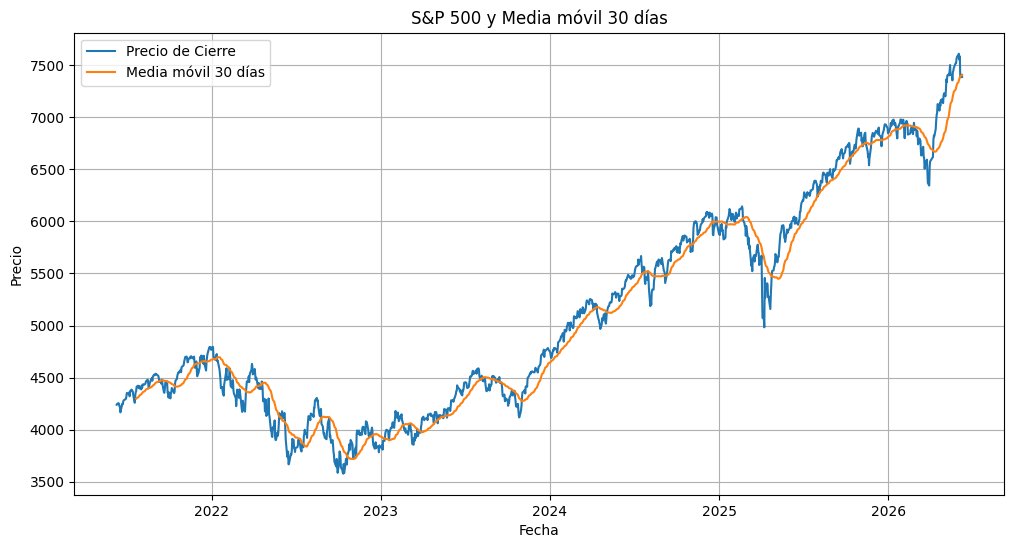

In [17]:
plt.figure(figsize=(12,6))

plt.plot(sp500.index, sp500["Close"], label="Precio de Cierre")

plt.plot(sp500.index, sp500["MA_30"], label="Media móvil 30 días")

plt.title("S&P 500 y Media móvil 30 días")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación Financiera

In [18]:
sp500.loc["2025-04-01":"2025-04-15",["Close","Daily_Return"]]

Price,Close,Daily_Return
Ticker,^GSPC,
Date,,
2025-04-01,5633.069824,0.003781
2025-04-02,5670.970215,0.006728
2025-04-03,5396.520020,-0.048396
2025-04-04,5074.080078,-0.059750
2025-04-07,5062.250000,-0.002331
2025-04-08,4982.770020,-0.015701
2025-04-09,5456.899902,0.095154
2025-04-10,5268.049805,-0.034608


El análisis exploratorio del S&P 500 para el periodo comprendido entre junio de 2021 y junio de 2026 evidencia una tendencia positiva de largo plazo en el nivel del índice. Sin embargo, la serie de rendimientos diarios presenta episodios de volatilidad significativa, reflejando cambios abruptos en las expectativas de los participantes del mercado.

La estadística descriptiva muestra un rendimiento diario promedio de aproximadamente 0.05%, acompañado de una desviación estándar cercana a 1.07%. Aunque la mayoría de los rendimientos se concentran alrededor de cero, se observan eventos extremos que exceden ampliamente la volatilidad típica de la muestra. En particular, el rendimiento mínimo registrado fue de -5.98%, mientras que el rendimiento máximo alcanzó 9.52%.

El análisis gráfico de los rendimientos sugiere la existencia de periodos de volatilidad agrupada (*volatility clustering*), fenómeno común en series financieras. Se identificó un periodo de volatilidad relativamente elevada durante 2022; sin embargo, el episodio más extremo ocurrió en abril de 2025, cuando se registraron tanto el peor como el mejor día de toda la muestra en un intervalo inferior a una semana.

La revisión del contexto económico indica que estos movimientos estuvieron asociados a anuncios de política comercial realizados por la administración estadounidense. La imposición de nuevos aranceles incrementó la incertidumbre respecto al crecimiento económico y a las condiciones futuras del comercio internacional, generando una fuerte corrección del mercado. Posteriormente, el anuncio de una suspensión temporal de dichas medidas redujo la percepción de riesgo sistémico y favoreció una recuperación significativa de los precios de los activos.

En resumen, los resultados muestran que las variaciones extremas del mercado suelen estar asociadas a eventos capaces de modificar rápidamente las expectativas de los inversionistas. Asimismo, evidencian la importancia de complementar el análisis cuantitativo de los rendimientos con la interpretación del entorno macroeconómico y financiero.
